# =============================================================================
# BASELINE DENSENET121 — TRAIN-TEST SPLIT EVALUATION
# =============================================================================
Evaluates the baseline DenseNet121 (frozen backbone → binary classification) on
**per-dataset** splits at configurable ratios (70:30, 80:20, 90:10).

Datasets: **CEDAR**, **BHSig-Bengali**, **BHSig-Hindi** (evaluated independently).

**Prerequisites:**
1. Run `scripts/prepare_split_ratios.py` to generate split JSONs.
2. Optionally have `baseline_pretrain.pth` from `baseline_pretraining.ipynb`.

# =============================================================================
# STEP 1: SETUP, IMPORTS, AND REPRODUCIBILITY
# =============================================================================

In [1]:
import os
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# Set repo root
current_dir = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# Import Custom Modules
from models.feature_extractor import DenseNetFeatureExtractor
from utils.model_evaluation import compute_metrics
from dataloader.tDCBAM_trainloader import get_baseline_transforms

# Deterministic Seeding
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f" > [System] Seed set to: {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [System] Device: {DEVICE}")
print(f" > [System] CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" > [System] CUDA Device Name: {torch.cuda.get_device_name()}")

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [System] Seed set to: 42
 > [System] Device: cuda
 > [System] CUDA Available: True
 > [System] CUDA Device Name: NVIDIA GeForce RTX 5080


# =============================================================================
# STEP 2: CONFIGURATION
# =============================================================================

In [2]:
# ── Input Configuration ──
IMG_SIZE = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)

# ── Training Hyperparameters ──
BATCH_SIZE = 30
EPOCHS = 60
PHASE1_EPOCHS = 15          # Phase 1: Frozen backbone (train custom_head)
LR_PHASE1 = 1e-3
LR_BACKBONE = 1e-5          # Phase 2: Differential LR
LR_HEAD = 1e-4

# Preprocessing & Augmentation
PREPROCESS = True            # Grayscale + Otsu + Invert
AUGMENT = True

# ── Dataset & Split Ratios ──
SPLIT_DIR = os.path.join(REPO_ROOT, 'data', 'ratio_splits')

DATASET = 'bhsig_bengali'
DATASET_NAME = 'BHSig-Bengali'
SPLIT_RATIOS = ['70_30', '80_20', '90_10']

# ── Pretrained Weights (from baseline_pretraining.ipynb) ──
PRETRAINED_WEIGHTS_PATH = os.path.join(REPO_ROOT, 'baseline_pretrain.pth')

# ── Checkpoint Directory ──
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'baseline_splits')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"[Config] Image Size: {INPUT_SHAPE}")
print(f"[Config] Batch Size: {BATCH_SIZE}")
print(f"[Config] Epochs: {EPOCHS} (Phase1: {PHASE1_EPOCHS}, Phase2: {EPOCHS - PHASE1_EPOCHS})")
print(f"[Config] Dataset: {DATASET_NAME}")
print(f"[Config] Splits: {SPLIT_RATIOS}")
print(f"[Config] Split Dir: {SPLIT_DIR}")
print(f"[Config] Pretrained: {PRETRAINED_WEIGHTS_PATH}")

if not os.path.exists(PRETRAINED_WEIGHTS_PATH):
    print(f"\nWARNING: Pretrained weights not found! Will use ImageNet initialization.")
else:
    print(f" > Pretrained weights found!")

[Config] Image Size: (224, 224)
[Config] Batch Size: 30
[Config] Epochs: 60 (Phase1: 15, Phase2: 45)
[Config] Dataset: BHSig-Bengali
[Config] Splits: ['70_30', '80_20', '90_10']
[Config] Split Dir: /home/lawrence/workspace/thesis/thesis/data/ratio_splits
[Config] Pretrained: /home/lawrence/workspace/thesis/thesis/baseline_pretrain.pth



# =============================================================================
# STEP 3: GENERATE SPLITS (if not already generated)
# =============================================================================

# =============================================================================
# STEP 4: DATASET CLASS AND TRANSFORMS
# =============================================================================

In [3]:
class SplitDataset(Dataset):
    """
    Binary classification dataset (Genuine=0, Forged=1) from split JSON.
    Works with CEDAR, BHSig-Bengali, and BHSig-Hindi split files.
    """
    def __init__(self, user_dict, transform=None):
        self.samples = []
        self.transform = transform
        
        for uid, data in user_dict.items():
            # Handle both key styles: 'genuine'/'forged' and 'gen'/'forg'
            gen_key = next((k for k in data.keys() if k.lower() in ['genuine', 'gen']), None)
            forg_key = next((k for k in data.keys() if k.lower() in ['forged', 'forgeries', 'forg']), None)
            
            if gen_key:
                for path in data[gen_key]:
                    self.samples.append((path, 0))  # 0 = Genuine
            if forg_key:
                for path in data[forg_key]:
                    self.samples.append((path, 1))  # 1 = Forged
        
        num_gen = sum(1 for _, l in self.samples if l == 0)
        num_forg = sum(1 for _, l in self.samples if l == 1)
        print(f"   Dataset: {len(self.samples)} samples ({num_gen} genuine + {num_forg} forged) from {len(user_dict)} users")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except Exception as e:
            img = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        return img, label

# Transforms
train_transform, val_transform = get_baseline_transforms(
    input_shape=INPUT_SHAPE, preprocess=PREPROCESS, augment=AUGMENT
)

print(" > Dataset class and transforms defined")

 > Dataset class and transforms defined


# =============================================================================
# STEP 5: TRAINING UTILITIES
# =============================================================================

In [4]:
def initialize_baseline_model(pretrained_path, device):
    """Initialize DenseNet121 baseline with optional pretrained weights."""
    num_classes = 2
    model = DenseNetFeatureExtractor(
        backbone_name='densenet121', output_dim=num_classes,
        pretrained=True, baseline=True
    ).to(device)
    
    if pretrained_path and os.path.exists(pretrained_path):
        checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
        state = checkpoint.get('model_state_dict', checkpoint)
        
        try:
            model.load_state_dict(state, strict=True)
            print(f"   Loaded pretrained weights (strict)")
        except RuntimeError:
            model_state = model.state_dict()
            filtered = {k: v for k, v in state.items() if k in model_state and model_state[k].shape == v.shape}
            model_state.update(filtered)
            model.load_state_dict(model_state)
            print(f"   Loaded {len(filtered)} compatible layers")
    else:
        print(f"   Using ImageNet initialization (pretrained weights)")
    
    return model


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch, returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def validate_one_epoch(model, loader, criterion, device):
    """Validate and compute metrics including EER."""
    model.eval()
    total_loss = 0.0
    all_labels, all_scores = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_scores.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    metrics = compute_metrics(all_labels, all_scores)
    metrics['loss'] = total_loss / len(loader)
    return metrics


def train_full_pipeline(model, train_loader, val_loader, device, 
                        epochs, phase1_epochs, lr_phase1, lr_backbone, lr_head,
                        checkpoint_path):
    """
    Full 2-phase training: frozen backbone → fine-tune all.
    Returns best metrics dict.
    """
    criterion = nn.CrossEntropyLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}
    
    # ── Phase 1: Frozen backbone ──
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr_phase1, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    for epoch in range(phase1_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)
        val_eer, val_acc = val_metrics['eer'], val_metrics['accuracy']
        
        print(f"   [P1] Epoch {epoch+1:02d}/{phase1_epochs} | Loss: {train_loss:.4f} | "
              f"Acc: {train_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({'model_state_dict': model.state_dict(), 'metrics': best_metrics}, checkpoint_path)
            print(f"   >>> Saved! (EER: {val_eer:.2%})")
    
    # ── Phase 2: Unfreeze backbone ──
    for param in model.backbone.parameters():
        param.requires_grad = True
    
    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': lr_backbone},
        {'params': model.custom_head.parameters(), 'lr': lr_head}
    ], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    phase2_epochs = epochs - phase1_epochs
    for epoch in range(phase2_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)
        val_eer, val_acc = val_metrics['eer'], val_metrics['accuracy']
        
        g_epoch = phase1_epochs + epoch + 1
        print(f"   [P2] Epoch {epoch+1:02d}/{phase2_epochs} (G:{g_epoch}) | Loss: {train_loss:.4f} | "
              f"Acc: {train_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({'model_state_dict': model.state_dict(), 'metrics': best_metrics}, checkpoint_path)
            print(f"   >>> Saved! (EER: {val_eer:.2%})")
    
    return best_metrics

print(" > Training utilities defined")

 > Training utilities defined


# =============================================================================
# STEP 6: RUN ALL SPLIT RATIOS
# =============================================================================

In [5]:
all_results = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    train_pct, test_pct = ratio.split('_')
    
    print(f"\n{'='*60}")
    print(f" {DATASET_NAME} — {train_pct}:{test_pct} Split")
    print(f"{'='*60}")
    
    if not os.path.exists(split_file):
        print(f"   SKIPPED: Split file not found: {split_file}")
        continue
    
    # Load split
    with open(split_file, 'r') as f:
        split_data = json.load(f)
    
    train_dict = split_data['train']
    test_dict = split_data['test']
    
    print(f"   Train users: {len(train_dict)} | Test users: {len(test_dict)}")
    
    # Create datasets
    print("   Creating train dataset...")
    train_dataset = SplitDataset(train_dict, transform=train_transform)
    print("   Creating test dataset...")
    test_dataset = SplitDataset(test_dict, transform=val_transform)
    
    if len(train_dataset) == 0 or len(test_dataset) == 0:
        print(f"   SKIPPED: Empty dataset")
        continue
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                              num_workers=4, pin_memory=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True)
    
    # Initialize model
    seed_everything(42)
    model = initialize_baseline_model(PRETRAINED_WEIGHTS_PATH, DEVICE)
    
    # Train
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{DATASET}_{ratio}.pth")
    best_metrics = train_full_pipeline(
        model, train_loader, test_loader, DEVICE,
        epochs=EPOCHS, phase1_epochs=PHASE1_EPOCHS,
        lr_phase1=LR_PHASE1, lr_backbone=LR_BACKBONE, lr_head=LR_HEAD,
        checkpoint_path=ckpt_path
    )
    
    # Record results
    result_key = f"{DATASET_NAME} ({train_pct}:{test_pct})"
    all_results[result_key] = {
        'dataset': DATASET_NAME,
        'split': f"{train_pct}:{test_pct}",
        'train_users': len(train_dict),
        'test_users': len(test_dict),
        'eer': float(best_metrics['eer']),
        'accuracy': float(best_metrics['accuracy']),
        'auc': float(best_metrics['auc']),
        'precision': float(best_metrics['precision']),
        'recall': float(best_metrics['recall']),
        'f1': float(best_metrics['f1']),
    }
    
    print(f"\n   RESULT: EER={best_metrics['eer']:.2%} | Acc={best_metrics['accuracy']:.2%} | "
          f"AUC={best_metrics['auc']:.4f} | F1={best_metrics['f1']:.4f}")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*60}")


 BHSig-Bengali — 70:30 Split
   Train users: 70 | Test users: 30
   Creating train dataset...
   Dataset: 3780 samples (1680 genuine + 2100 forged) from 70 users
   Creating test dataset...
   Dataset: 1620 samples (720 genuine + 900 forged) from 30 users
 > [System] Seed set to: 42
   Using ImageNet initialization (pretrained weights)


Training:   0%|          | 0/126 [00:00<?, ?it/s]

   [P1] Epoch 01/15 | Loss: 0.5360 | Acc: 73.60% | Val EER: 19.72% | Val Acc: 80.25%
   >>> Saved! (EER: 19.72%)


Training:   0%|          | 0/126 [00:00<?, ?it/s]

   [P1] Epoch 02/15 | Loss: 0.4538 | Acc: 79.39% | Val EER: 19.86% | Val Acc: 80.19%


...

   [P2] Epoch 43/45 (G:58) | Loss: 0.0503 | Acc: 98.17% | Val EER: 13.33% | Val Acc: 86.67%


Training:   0%|          | 0/162 [00:00<?, ?it/s]

   [P2] Epoch 44/45 (G:59) | Loss: 0.0443 | Acc: 98.27% | Val EER: 12.92% | Val Acc: 87.22%


Training:   0%|          | 0/162 [00:00<?, ?it/s]

   [P2] Epoch 45/45 (G:60) | Loss: 0.0457 | Acc: 98.33% | Val EER: 12.92% | Val Acc: 86.85%

   RESULT: EER=12.08% | Acc=88.15% | AUC=0.9376 | F1=0.8923

ALL EXPERIMENTS COMPLETE


# =============================================================================
# STEP 7: SUMMARY TABLE
# =============================================================================

In [6]:
# Print summary table
print(f"\n{'='*70}")
print(f"{'BASELINE DENSENET121 — ' + DATASET_NAME + ' SPLIT EVALUATION':^70}")
print(f"{'='*70}")
print(f"{'Split':<10} {'Train':<8} {'Test':<8} {'EER':<10} {'Accuracy':<10} {'AUC':<10} {'F1':<10}")
print(f"{'-'*70}")

for key, res in all_results.items():
    print(f"{res['split']:<10} {res['train_users']:<8} {res['test_users']:<8} "
          f"{res['eer']:.4f}    {res['accuracy']:.4f}    {res['auc']:.4f}    {res['f1']:.4f}")

print(f"{'='*70}")

# Save results
results_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n > Results saved to: {results_path}")


        BASELINE DENSENET121 — BHSig-Bengali SPLIT EVALUATION         
Split      Train    Test     EER        Accuracy   AUC        F1        
----------------------------------------------------------------------
70:30      70       30       0.1153    0.8833    0.9552    0.8936
80:20      80       20       0.1417    0.8556    0.9434    0.8678
90:10      90       10       0.1208    0.8815    0.9376    0.8923

 > Results saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_bhsig_bengali_results.json


# =============================================================================
# STEP 8: VISUALIZATION
# =============================================================================

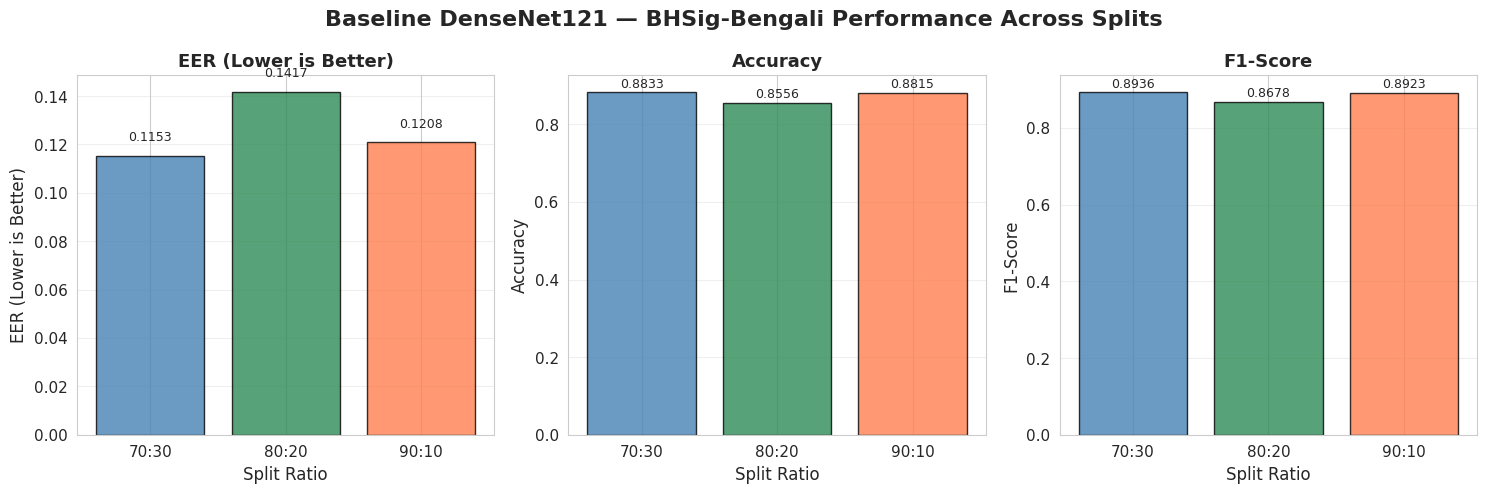

 > Plot saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/baseline_splits/baseline_bhsig_bengali_comparison.png


In [7]:
# Bar chart: Metrics by split ratio
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Baseline DenseNet121 — {DATASET_NAME} Performance Across Splits', fontsize=16, fontweight='bold')

metrics_to_plot = ['eer', 'accuracy', 'f1']
titles = ['EER (Lower is Better)', 'Accuracy', 'F1-Score']
colors = ['steelblue', 'seagreen', 'coral']

for ax_idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[ax_idx]
    split_labels = []
    values = []
    
    for ratio in SPLIT_RATIOS:
        split_str = ratio.replace('_', ':')
        split_labels.append(split_str)
        key = f"{DATASET_NAME} ({split_str})"
        values.append(all_results.get(key, {}).get(metric, 0))
    
    bars = ax.bar(split_labels, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'baseline_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved to: {plot_path}")